## Use 3D decon for 2D images


Load the images and assign the wavelengths

In [2]:
from skimage.io import imread
from tnia.plotting.plt_helper import imshow2d
import numpy as np

im_path = r"D:\images\tnia-python-images\deconvolution\c.elegans\\"
im_name = r"CElegans-CY3.tif"

image = imread(im_path + im_name)

print(type(image), print(image.shape), print(image.dtype), print(image.min()), print(image.max()))

xy_spacing = 0.0645
z_spacing = 0.160


(104, 712, 672)
uint16
215
2842
<class 'numpy.ndarray'> None None None None


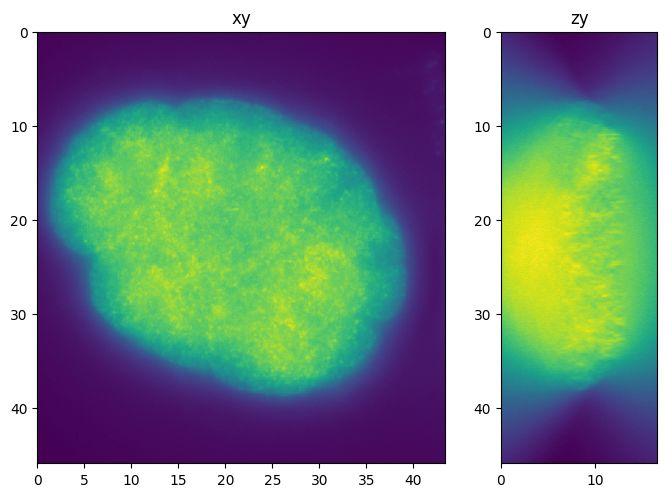

In [3]:
from tnia.plotting.projections import show_xy_zy_slice_center


fig = show_xy_zy_slice_center(image, figsize=(8,8),sxy=xy_spacing, sz=z_spacing)

## Generate a PSF

sdeconv 1.x.x detected


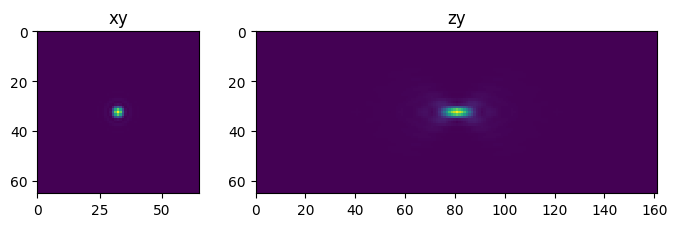

In [5]:
from tnia.deconvolution.psfs import gibson_lanni_3D
from tnia.plotting.projections import show_xy_zy_slice_center
import numpy as np
import matplotlib.pyplot as plt

xy_psf_dim = 65
NA = 1.4
x_voxel_size = 0.0645
z_voxel_size = 0.160
z_psf_dim = 65 
ni = 1.51
ns = 1.4
defocus = 0
wavelength = 0.550

psf = gibson_lanni_3D(NA, ni, ns, x_voxel_size, z_voxel_size, xy_psf_dim, z_psf_dim, defocus, wavelength)
fig = show_xy_zy_slice_center(psf, sz=z_voxel_size/x_voxel_size, figsize=(8, 3))

## Deconvolve the image 3 ways

1.  Full 3D
2.  2D slice 3D PSF
3.  2D slice 2D PSF


In [6]:
#images[i] = images[i][None, ...]
#print(images[i].shape)

In [7]:
from tnia.deconvolution.richardson_lucy import richardson_lucy_cp
from tnia.deconvolution.decon_helper import create_saturation_mask

import timeit

num_iterations = 500
decon_full_3D = richardson_lucy_cp(image, psf, num_iterations, noncirc=True)


Input size: (104, 712, 672), PSF size: (65, 65, 65)

0 10 20 30 40 50 60 70 80 90 100 110 120 130 140 150 160 170 180 190 200 210 220 230 240 250 260 270 280 290 300 310 320 330 340 350 360 370 380 390 400 410 420 430 440 450 460 470 480 490 


In [10]:
num_iterations = 25 
center_slice = image[image.shape[0]//2]
# add trivial dimension to image
center_slice = center_slice[None, ...]
decon_2D_3D = richardson_lucy_cp(center_slice, psf, num_iterations, noncirc=True)

Input size: (1, 712, 672), PSF size: (65, 65, 65)
Input is 2D (single Z plane), PSF is 3D
EXPERIMENTAL: 3D DECON OF 2D SLICE WILL BE DONE

0 10 20 


In [18]:
50
decon_2D = richardson_lucy_cp(image[image.shape[0]//2], psf[psf.shape[0]//2]/psf[psf.shape[0]//2].sum(), num_iterations, noncirc=True)

Input size: (712, 672), PSF size: (65, 65)
Input is 2D, PSF is 2D

0 10 20 


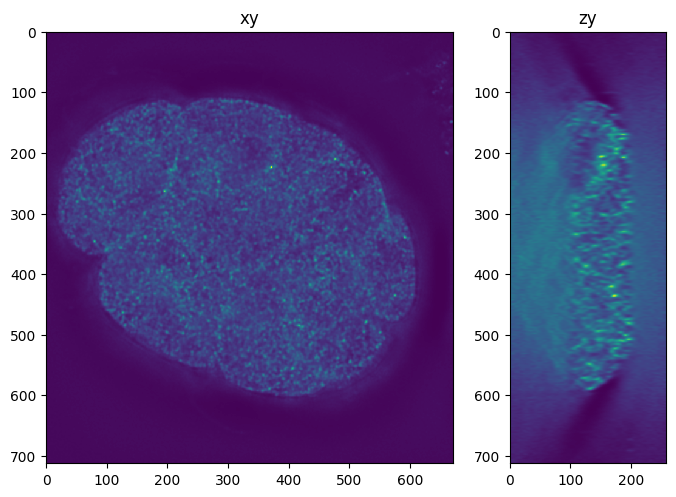

In [8]:
fig = show_xy_zy_slice_center(decon_full_3D, sz=z_spacing/xy_spacing, figsize=(8,8))

Take a look at 3d slice projections (even though we are deconvolving a 3D image, we are reconstructing in a 3d space)

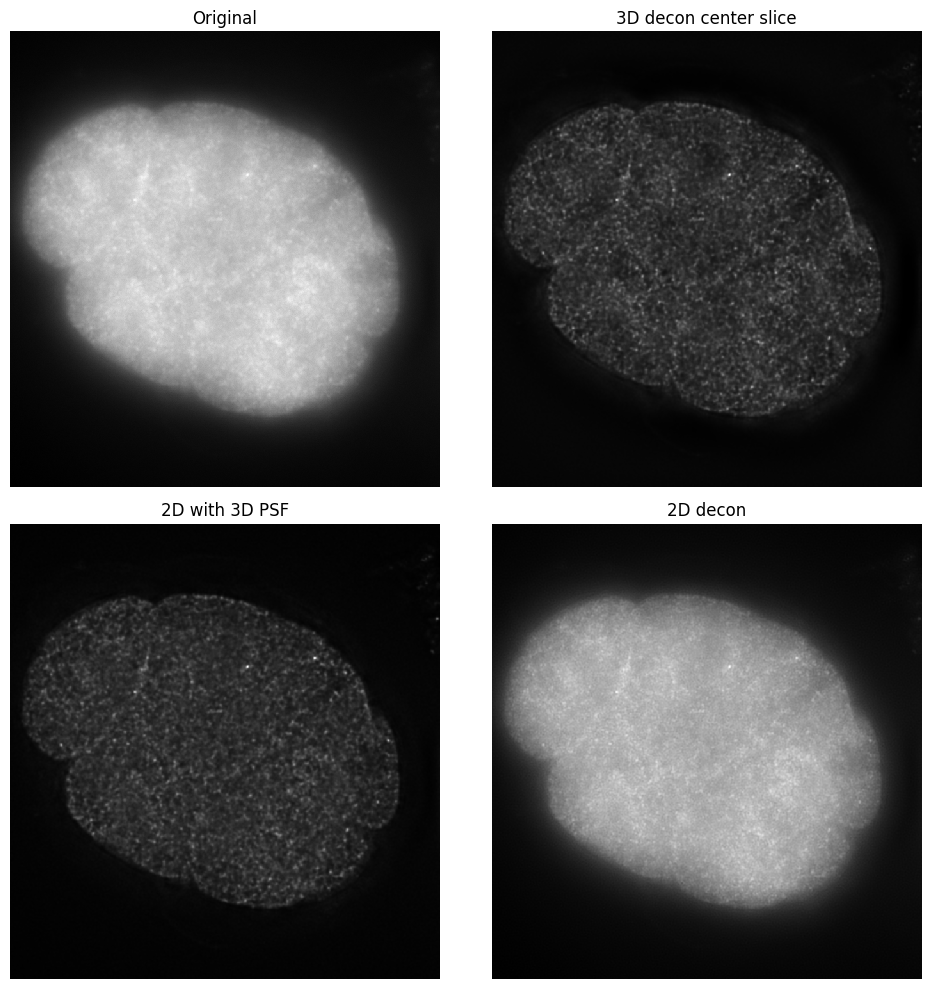

In [19]:
import matplotlib.pyplot as plt

z = image.shape[0] // 2
orig = image[z]
d3d = decon_full_3D[decon_full_3D.shape[0] // 2]
d2d_from_3d = decon_2D_3D.squeeze()
d2d = decon_2D

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes[0, 0].imshow(orig, cmap='gray'); axes[0, 0].set_title('Original'); axes[0, 0].axis('off')
axes[0, 1].imshow(d3d, cmap='gray'); axes[0, 1].set_title('3D decon center slice'); axes[0, 1].axis('off')
axes[1, 0].imshow(d2d_from_3d, cmap='gray'); axes[1, 0].set_title('2D with 3D PSF'); axes[1, 0].axis('off')
axes[1, 1].imshow(d2d, cmap='gray'); axes[1, 1].set_title('2D decon'); axes[1, 1].axis('off')
plt.tight_layout()
plt.show()

In [16]:
import napari
viewer = napari.Viewer()
viewer.add_image(orig, name='Input Image')
viewer.add_image(d3d, name='Deconvolved Image')
viewer.add_image(d2d_from_3d, name='2D Decon with 3D PSF')
viewer.add_image(d2d, name='2D Decon with 2D PSF')


<Image layer '2D Decon with 2D PSF' at 0x20180c86490>

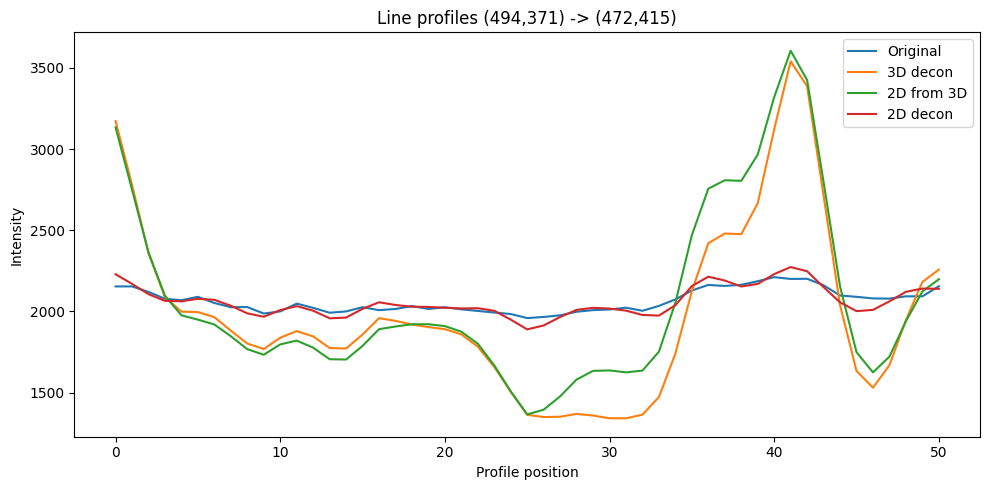

In [20]:
from skimage.measure import profile_line
import matplotlib.pyplot as plt

src = (371, 494)
dst = (415, 472)

profiles = [
    ('Original',      orig,        profile_line(orig,        src, dst)),
    ('3D decon',      d3d,         profile_line(d3d,         src, dst)),
    ('2D from 3D',    d2d_from_3d, profile_line(d2d_from_3d, src, dst)),
    ('2D decon',      d2d,         profile_line(d2d,         src, dst)),
]

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
for (label, _, prof), color in zip(profiles, colors):
    ax.plot(prof, label=label, color=color)
ax.set_xlabel('Profile position')
ax.set_ylabel('Intensity')
ax.set_title('Line profiles (494,371) -> (472,415)')
ax.legend()
plt.tight_layout()
plt.show()